In [ ]:
# Librerías y Configuración Inicial
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, \
    precision_score, recall_score, f1_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import gc
import stanza
import os
import numpy as np
import math
from collections import Counter
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler 
import warnings
warnings.filterwarnings('ignore')

# Stanza y BERT
stanza.download("es", verbose=False)
nlp_stanza = stanza.Pipeline("es", processors="tokenize,pos,lemma")
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model_bert = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model_bert.to(device)
print(f"Usando dispositivo: {device}")



c:\Users\Sistemas\anaconda3\envs\entorno_actualizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Usando dispositivo: cuda


In [2]:
# Datos
DATA_PATH = r"C:\Users\Sistemas\Desktop\PFINAL\nuevo_df.csv"
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
#df = df.head(300)

if "clean_text" not in df.columns:
    txt_col = next(c for c in df.select_dtypes("object").columns if c != "Nivel_f")
    pref = os.path.commonprefix(df[txt_col].tolist())
    df["clean_text"] = df[txt_col].str[len(pref):].str.strip()

label_encoder = LabelEncoder()
df["etiqueta_codificada"] = label_encoder.fit_transform(df["Nivel_f"])

print(df[["Nivel_f", "clean_text"]].head())
print(df["Nivel_f"].value_counts())

X_text = df["clean_text"]
y = df["etiqueta_codificada"]
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)



      Nivel_f                                         clean_text
0  Medio bajo  otro aspecto que podemos tener en cuenta es la...
1  Medio alto  En segundo lugar, el aprendizaje de lectura y ...
2  Medio bajo  en segundo lugar, fomentando estas practicas d...
3  Medio bajo  En segundo lugar, la lectura y escritura es fu...
4  Medio bajo  La lectura y la escritura son importantes para...
Nivel_f
Medio alto    687
Medio bajo    644
Bajo          310
Alto          279
Name: count, dtype: int64


In [3]:
from itertools import product
dropout_grid = [0.2, 0.4]
learning_rate_grid = [2e-5, 5e-5, 1e-4]
n_splits_grid = [3]
EPOCHS = 30 

# Funciones de Features Lingüísticas y Distancias
def extraer_caracteristicas_avanzadas(texto, tokenizer, model, device):
    doc = nlp_stanza(texto)
    oraciones = [s.text for s in doc.sentences]
    palabras = [w.text.lower() for s in doc.sentences for w in s.words if w.text.isalpha()]
    tipos = set(palabras)
    tokens = len(palabras)
    tipos_count = len(tipos)
    hapax = sum(1 for v in Counter(palabras).values() if v == 1)
    ttr = tipos_count / tokens if tokens else 0
    rttr = tipos_count / np.sqrt(2 * tokens) if tokens else 0
    cttr = tipos_count / np.sqrt(2 * tokens) if tokens else 0
    maas = (math.log(tokens) - math.log(tipos_count)) / (math.log(tokens)**2) if tokens > 1 and tipos_count > 1 else 0
    herdan = math.log(tipos_count) / math.log(tokens) if tokens > 1 and tipos_count > 1 else 0
    honore = 100 * math.log(tokens) / (1 - (hapax / tipos_count)) if tipos_count > 1 and (1 - (hapax / tipos_count)) != 0 else 0
    def mattr(palabras, window_size=50):
        if len(palabras) < window_size:
            return ttr
        return np.mean([len(set(palabras[i:i+window_size]))/window_size
                        for i in range(len(palabras)-window_size+1)])
    def mtld(palabras, threshold=0.72):
        factors, factor_length, ttr_temp = 0, 0, []
        for i, word in enumerate(palabras, 1):
            ttr_temp.append(word)
            if len(set(ttr_temp)) / len(ttr_temp) <= threshold:
                factors += 1
                factor_length += len(ttr_temp)
                ttr_temp = []
        if ttr_temp:
            factors += 1
            factor_length += len(ttr_temp)
        return factor_length / factors if factors else 0
    mattr_val = mattr(palabras)
    mtld_val = mtld(palabras)
    parrafos = [p for p in texto.split('\n') if p.strip()]
    n_parrafos = len(parrafos)
    n_oraciones = len(oraciones)
    oraciones_lens = [len([w for w in s.split() if w.isalpha()]) for s in oraciones]
    parrafos_lens = [len([w for w in p.split() if w.isalpha()]) for p in parrafos]
    return {
        "ttr": ttr, "rttr": rttr, "cttr": cttr, "mattr": mattr_val, "mtld": mtld_val,
        "honore": honore, "maas": maas, "herdan": herdan,
        "prom_oraciones_por_parrafo": n_oraciones / n_parrafos if n_parrafos else 0,
        "prom_longitud_oracion": np.mean(oraciones_lens) if oraciones_lens else 0,
        "desv_longitud_oracion": np.std(oraciones_lens) if oraciones_lens else 0,
        "prom_longitud_parrafo": np.mean(parrafos_lens) if parrafos_lens else 0,
        "desv_longitud_parrafo": np.std(parrafos_lens) if parrafos_lens else 0,
    }

def tokenizar_datos(textos, tokenizer, max_len=512):
    return tokenizer(
        textos,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

def obtener_embedding_promedio(texto, tokenizer, model, device):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding_texto = outputs.last_hidden_state.mean(dim=1).cpu().detach().numpy().squeeze()
    return embedding_texto

def calcular_centroides_por_clase(X_text_train, y_train, tokenizer, model, device):
    centroids = {}
    y_arr = np.array(y_train)
    for class_idx in np.unique(y_arr):
        idxs = np.where(y_arr == class_idx)[0]
        textos = X_text_train.iloc[idxs].tolist()
        embeddings = [obtener_embedding_promedio(t, tokenizer, model, device) for t in textos]
        centroids[class_idx] = np.mean(embeddings, axis=0)
    return centroids

def agregar_distancia_a_centroides(texto, tokenizer, model, device, class_centroids):
    embedding = obtener_embedding_promedio(texto, tokenizer, model, device)
    return {f"dist_centroide_{cls}": np.linalg.norm(embedding - centroid) for cls, centroid in class_centroids.items()}



In [ ]:
# 3. Modelos y Dataset
class TextDataset(Dataset):
    def __init__(self, encodings, features, labels):
        self.encodings = encodings
        self.features = features.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['features'] = torch.tensor(self.features.iloc[idx].values, dtype=torch.float)
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch_size, seq_len, hidden_dim)
        attn_weights = F.softmax(self.attn(lstm_output), dim=1)  # (batch_size, seq_len, 1)
        context = torch.sum(attn_weights * lstm_output, dim=1)   # (batch_size, hidden_dim)
        return context

class BiLSTM_CNN_Text_Classifier(nn.Module):
    def __init__(self, bert_model, lstm_hidden_dim, n_filters, filter_sizes, output_dim, dropout, n_linguistic_features):
        super().__init__()
        self.bert = bert_model
        embedding_dim = self.bert.config.hidden_size
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, num_layers=2, bidirectional=True, batch_first=True)
        self.attn = Attention(2 * lstm_hidden_dim)  # BiLSTM output dim
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=n_filters, kernel_size=(fs, 2 * lstm_hidden_dim))
            for fs in filter_sizes
        ])
        self.fc1 = nn.Linear(len(filter_sizes) * n_filters + 2 * lstm_hidden_dim + n_linguistic_features, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, features):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = bert_outputs.last_hidden_state    # (batch, seq_len, bert_dim)
        lstm_out, _ = self.lstm(embeddings)            # (batch, seq_len, 2*lstm_h)
        attn_vec = self.attn(lstm_out)                 # (batch, 2*lstm_h)
        lstm_out_unsq = lstm_out.unsqueeze(1)          # (batch, 1, seq_len, 2*lstm_h)
        conved = [torch.relu(conv(lstm_out_unsq)).squeeze(3) for conv in self.convs]
        pooled = [torch.max(conv, dim=2)[0] for conv in conved]
        cat_cnn = self.dropout(torch.cat(pooled, dim=1))
        # Fusionamos [CNN features | Attention | Ling features]
        cat = torch.cat((cat_cnn, attn_vec, features), dim=1)
        x = self.dropout(F.relu(self.bn1(self.fc1(cat))))
        return self.fc2(x)





>>> Entrenando con dropout=0.2, lr=2e-05, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.2-2e-05-3 | Epoch 01 |TrainAcc 0.278 | ValAcc 0.205 | MacroF1 0.151
Grid 0.2-2e-05-3 | Epoch 02 |TrainAcc 0.280 | ValAcc 0.248 | MacroF1 0.189
Grid 0.2-2e-05-3 | Epoch 03 |TrainAcc 0.291 | ValAcc 0.289 | MacroF1 0.211
Descongelada capa BERT 10
Grid 0.2-2e-05-3 | Epoch 04 |TrainAcc 0.279 | ValAcc 0.307 | MacroF1 0.232
Grid 0.2-2e-05-3 | Epoch 05 |TrainAcc 0.277 | ValAcc 0.305 | MacroF1 0.235
Grid 0.2-2e-05-3 | Epoch 06 |TrainAcc 0.282 | ValAcc 0.316 | MacroF1 0.252
Descongelada capa BERT 9
Grid 0.2-2e-05-3 | Epoch 07 |TrainAcc 0.298 | ValAcc 0.324 | MacroF1 0.260
Grid 0.2-2e-05-3 | Epoch 08 |TrainAcc 0.298 | ValAcc 0.342 | MacroF1 0.274
Grid 0.2-2e-05-3 | Epoch 09 |TrainAcc 0.285 | ValAcc 0.352 | MacroF1 0.278
Descongelada capa BERT 8
Grid 0.2-2e-05-3 | Epoch 10 |TrainAcc 0.297 | ValAcc 0.355 | MacroF1 0.293
Grid 0.2-2e-05-3 | Epoch 11 |TrainAcc 0.298 | ValAcc 0.361 | MacroF1

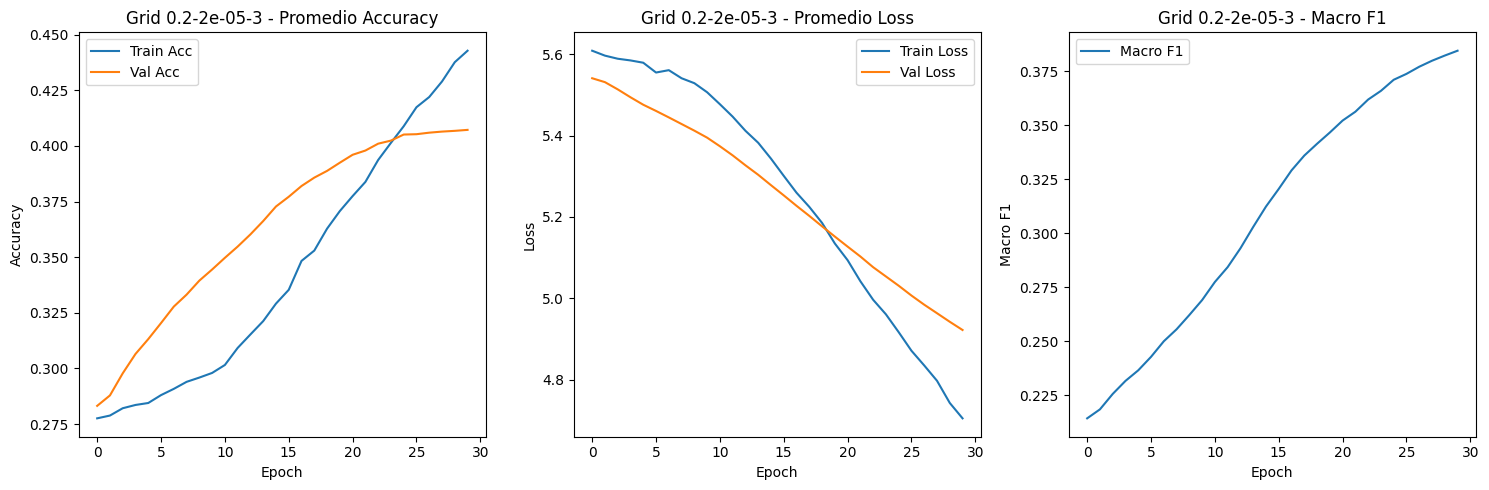


>>> Entrenando con dropout=0.2, lr=5e-05, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.2-5e-05-3 | Epoch 01 |TrainAcc 0.282 | ValAcc 0.279 | MacroF1 0.257
Grid 0.2-5e-05-3 | Epoch 02 |TrainAcc 0.289 | ValAcc 0.258 | MacroF1 0.265
Grid 0.2-5e-05-3 | Epoch 03 |TrainAcc 0.286 | ValAcc 0.236 | MacroF1 0.243
Descongelada capa BERT 10
Grid 0.2-5e-05-3 | Epoch 04 |TrainAcc 0.305 | ValAcc 0.230 | MacroF1 0.231
Grid 0.2-5e-05-3 | Epoch 05 |TrainAcc 0.291 | ValAcc 0.225 | MacroF1 0.226
Grid 0.2-5e-05-3 | Epoch 06 |TrainAcc 0.292 | ValAcc 0.225 | MacroF1 0.225
Descongelada capa BERT 9
Grid 0.2-5e-05-3 | Epoch 07 |TrainAcc 0.325 | ValAcc 0.229 | MacroF1 0.228
Early-Stopping en 5 épocas sin mejora

--- Procesando Fold 2/3 ---
Descongelada capa BERT 11
Grid 0.2-5e-05-3 | Epoch 01 |TrainAcc 0.292 | ValAcc 0.186 | MacroF1 0.124
Grid 0.2-5e-05-3 | Epoch 02 |TrainAcc 0.313 | ValAcc 0.221 | MacroF1 0.183
Grid 0.2-5e-05-3 | Epoch 03 |TrainAcc 0.281 | ValAcc 0.219 | MacroF1 0.193


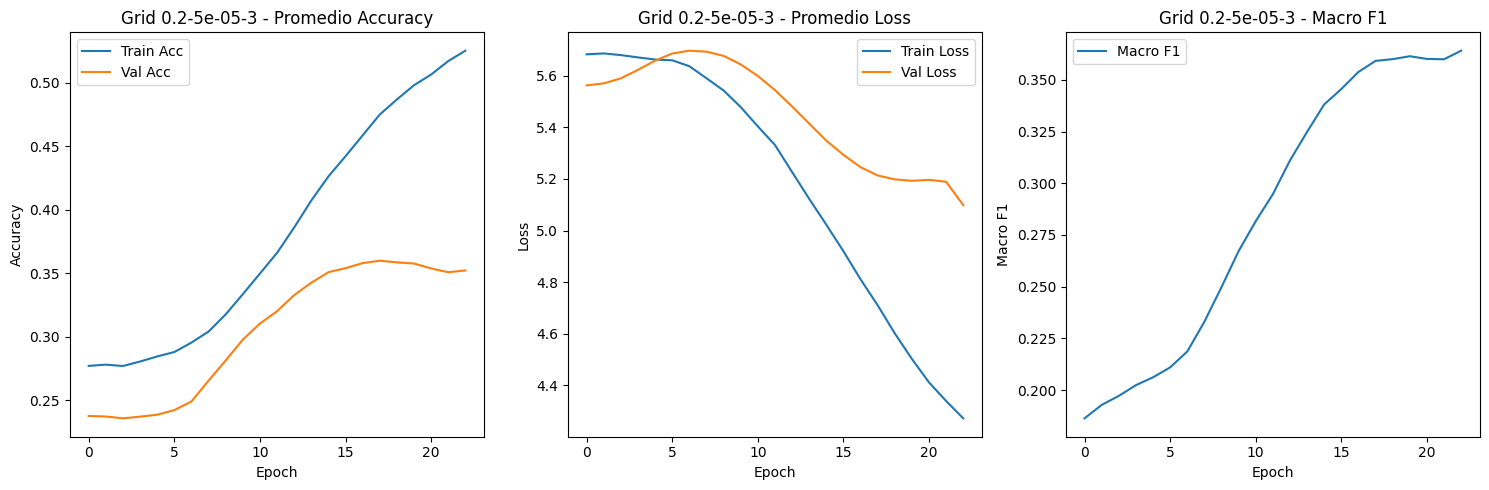


>>> Entrenando con dropout=0.2, lr=0.0001, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.2-0.0001-3 | Epoch 01 |TrainAcc 0.268 | ValAcc 0.373 | MacroF1 0.204
Grid 0.2-0.0001-3 | Epoch 02 |TrainAcc 0.275 | ValAcc 0.387 | MacroF1 0.250
Grid 0.2-0.0001-3 | Epoch 03 |TrainAcc 0.257 | ValAcc 0.367 | MacroF1 0.242
Descongelada capa BERT 10
Grid 0.2-0.0001-3 | Epoch 04 |TrainAcc 0.283 | ValAcc 0.363 | MacroF1 0.245
Grid 0.2-0.0001-3 | Epoch 05 |TrainAcc 0.289 | ValAcc 0.379 | MacroF1 0.259
Grid 0.2-0.0001-3 | Epoch 06 |TrainAcc 0.291 | ValAcc 0.391 | MacroF1 0.272
Descongelada capa BERT 9
Grid 0.2-0.0001-3 | Epoch 07 |TrainAcc 0.299 | ValAcc 0.398 | MacroF1 0.278
Grid 0.2-0.0001-3 | Epoch 08 |TrainAcc 0.316 | ValAcc 0.418 | MacroF1 0.301
Grid 0.2-0.0001-3 | Epoch 09 |TrainAcc 0.341 | ValAcc 0.449 | MacroF1 0.340
Descongelada capa BERT 8
Grid 0.2-0.0001-3 | Epoch 10 |TrainAcc 0.370 | ValAcc 0.469 | MacroF1 0.369
Grid 0.2-0.0001-3 | Epoch 11 |TrainAcc 0.415 | ValAcc 0.4

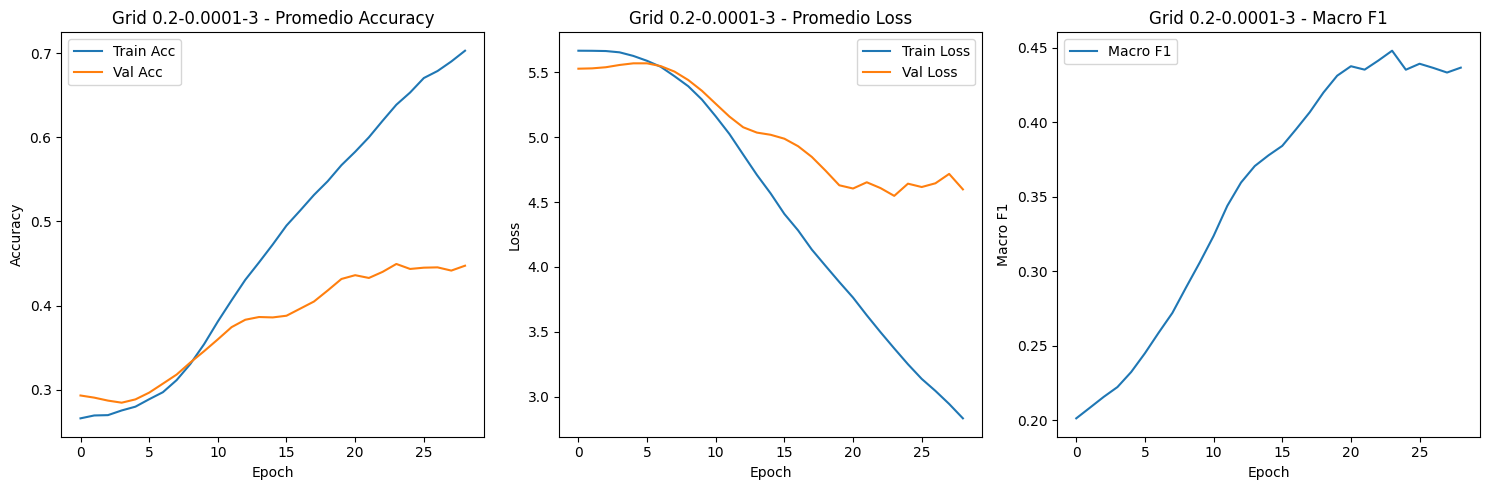


>>> Entrenando con dropout=0.4, lr=2e-05, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.4-2e-05-3 | Epoch 01 |TrainAcc 0.227 | ValAcc 0.129 | MacroF1 0.061
Grid 0.4-2e-05-3 | Epoch 02 |TrainAcc 0.214 | ValAcc 0.133 | MacroF1 0.083
Grid 0.4-2e-05-3 | Epoch 03 |TrainAcc 0.244 | ValAcc 0.172 | MacroF1 0.141
Descongelada capa BERT 10
Grid 0.4-2e-05-3 | Epoch 04 |TrainAcc 0.228 | ValAcc 0.189 | MacroF1 0.157
Grid 0.4-2e-05-3 | Epoch 05 |TrainAcc 0.219 | ValAcc 0.209 | MacroF1 0.178
Grid 0.4-2e-05-3 | Epoch 06 |TrainAcc 0.213 | ValAcc 0.217 | MacroF1 0.186
Descongelada capa BERT 9
Grid 0.4-2e-05-3 | Epoch 07 |TrainAcc 0.204 | ValAcc 0.221 | MacroF1 0.186
Grid 0.4-2e-05-3 | Epoch 08 |TrainAcc 0.217 | ValAcc 0.223 | MacroF1 0.187
Grid 0.4-2e-05-3 | Epoch 09 |TrainAcc 0.228 | ValAcc 0.230 | MacroF1 0.195
Descongelada capa BERT 8
Grid 0.4-2e-05-3 | Epoch 10 |TrainAcc 0.236 | ValAcc 0.223 | MacroF1 0.193
Grid 0.4-2e-05-3 | Epoch 11 |TrainAcc 0.233 | ValAcc 0.230 | MacroF1

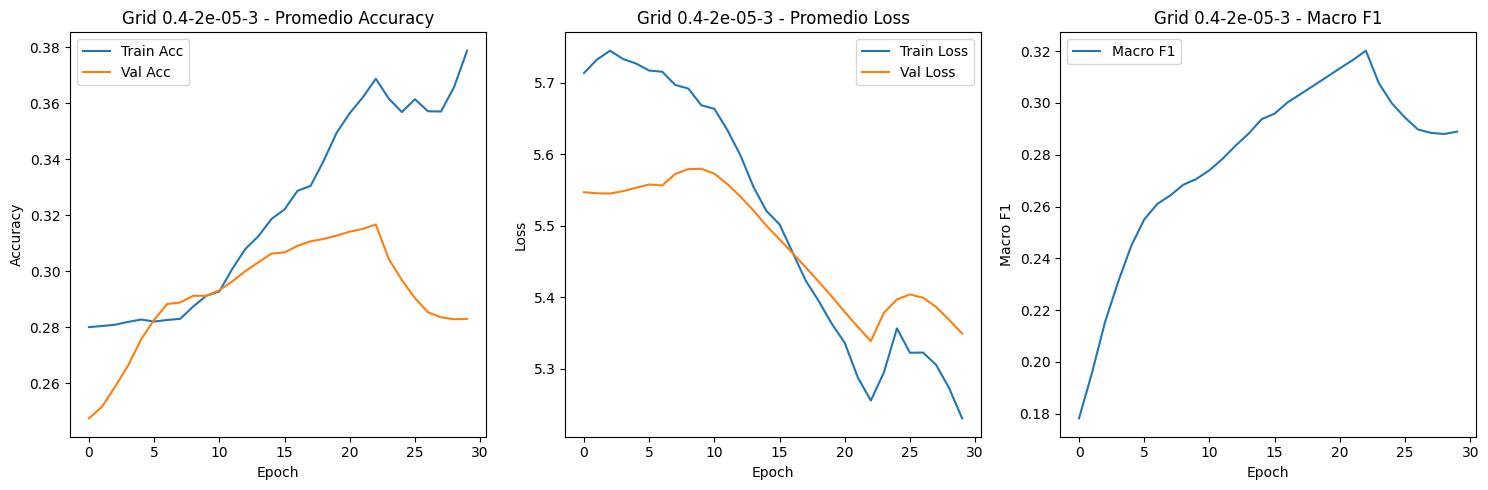


>>> Entrenando con dropout=0.4, lr=5e-05, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.4-5e-05-3 | Epoch 01 |TrainAcc 0.299 | ValAcc 0.254 | MacroF1 0.223
Grid 0.4-5e-05-3 | Epoch 02 |TrainAcc 0.286 | ValAcc 0.273 | MacroF1 0.255
Grid 0.4-5e-05-3 | Epoch 03 |TrainAcc 0.288 | ValAcc 0.279 | MacroF1 0.268
Descongelada capa BERT 10
Grid 0.4-5e-05-3 | Epoch 04 |TrainAcc 0.270 | ValAcc 0.279 | MacroF1 0.269
Grid 0.4-5e-05-3 | Epoch 05 |TrainAcc 0.295 | ValAcc 0.285 | MacroF1 0.273
Grid 0.4-5e-05-3 | Epoch 06 |TrainAcc 0.311 | ValAcc 0.289 | MacroF1 0.276
Descongelada capa BERT 9
Grid 0.4-5e-05-3 | Epoch 07 |TrainAcc 0.298 | ValAcc 0.297 | MacroF1 0.288
Grid 0.4-5e-05-3 | Epoch 08 |TrainAcc 0.316 | ValAcc 0.309 | MacroF1 0.297
Grid 0.4-5e-05-3 | Epoch 09 |TrainAcc 0.339 | ValAcc 0.326 | MacroF1 0.314
Descongelada capa BERT 8
Grid 0.4-5e-05-3 | Epoch 10 |TrainAcc 0.326 | ValAcc 0.334 | MacroF1 0.316
Grid 0.4-5e-05-3 | Epoch 11 |TrainAcc 0.350 | ValAcc 0.338 | MacroF1

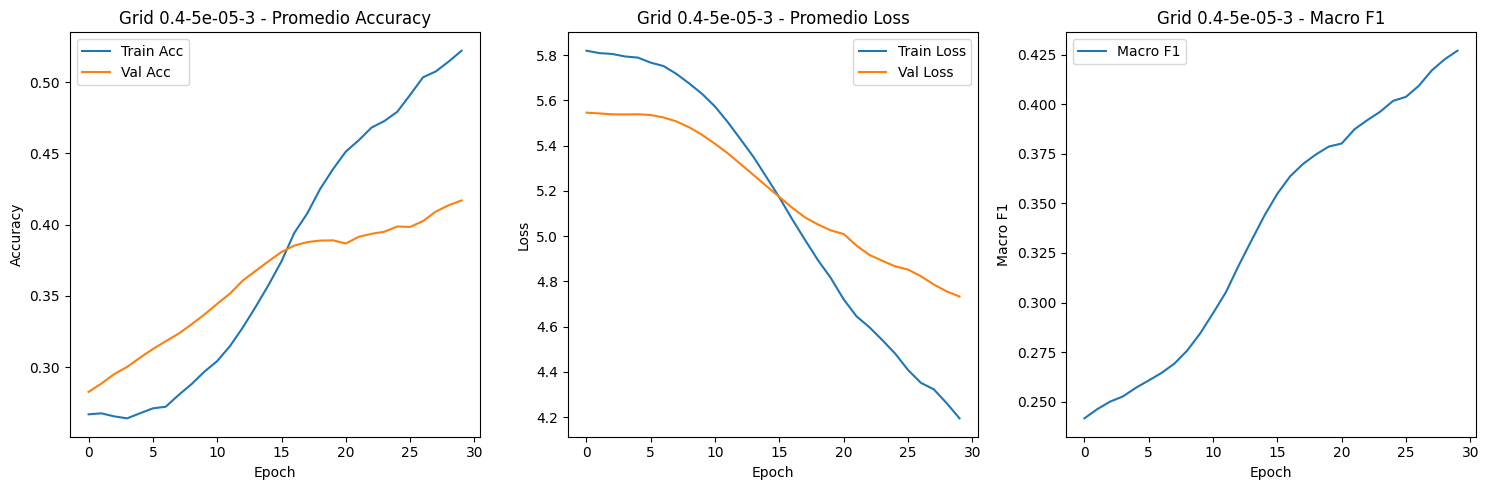


>>> Entrenando con dropout=0.4, lr=0.0001, folds=3

--- Procesando Fold 1/3 ---
Descongelada capa BERT 11
Grid 0.4-0.0001-3 | Epoch 01 |TrainAcc 0.263 | ValAcc 0.334 | MacroF1 0.171
Grid 0.4-0.0001-3 | Epoch 02 |TrainAcc 0.252 | ValAcc 0.326 | MacroF1 0.161
Grid 0.4-0.0001-3 | Epoch 03 |TrainAcc 0.272 | ValAcc 0.320 | MacroF1 0.172
Descongelada capa BERT 10
Grid 0.4-0.0001-3 | Epoch 04 |TrainAcc 0.266 | ValAcc 0.322 | MacroF1 0.185
Grid 0.4-0.0001-3 | Epoch 05 |TrainAcc 0.289 | ValAcc 0.324 | MacroF1 0.199
Grid 0.4-0.0001-3 | Epoch 06 |TrainAcc 0.266 | ValAcc 0.328 | MacroF1 0.219
Descongelada capa BERT 9
Grid 0.4-0.0001-3 | Epoch 07 |TrainAcc 0.304 | ValAcc 0.334 | MacroF1 0.227
Grid 0.4-0.0001-3 | Epoch 08 |TrainAcc 0.307 | ValAcc 0.363 | MacroF1 0.277
Grid 0.4-0.0001-3 | Epoch 09 |TrainAcc 0.321 | ValAcc 0.418 | MacroF1 0.348
Descongelada capa BERT 8
Grid 0.4-0.0001-3 | Epoch 10 |TrainAcc 0.338 | ValAcc 0.430 | MacroF1 0.363
Grid 0.4-0.0001-3 | Epoch 11 |TrainAcc 0.387 | ValAcc 0.4

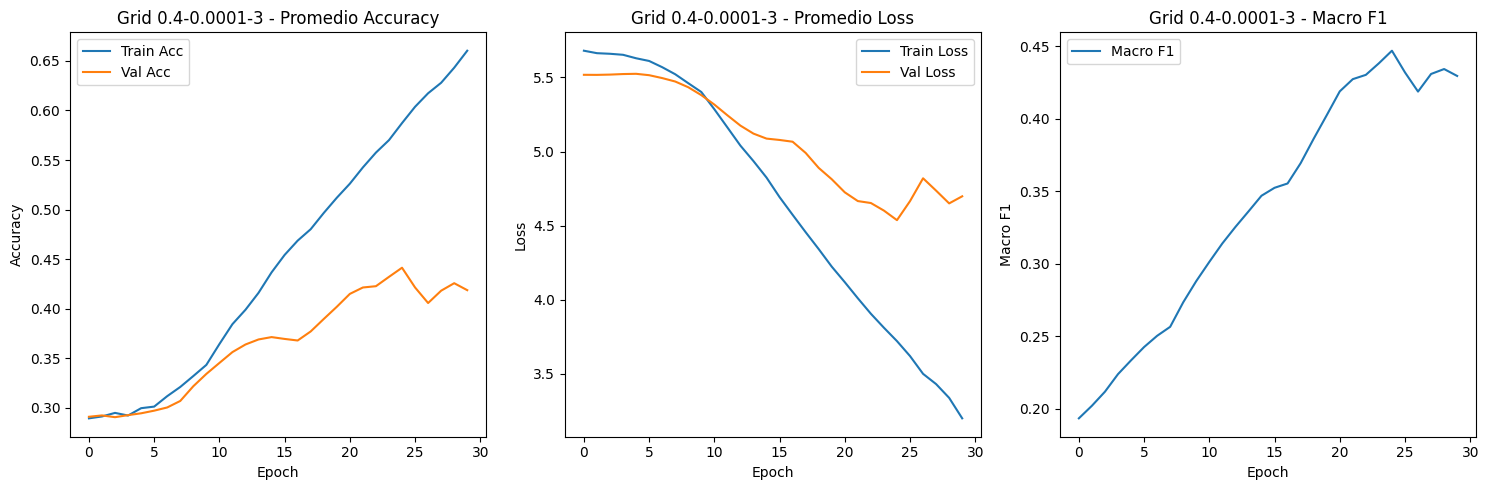

In [5]:
# Pipeline de entrenamiento y busqueda
resultados_grid, ensemble_preds_test, ensemble_probs_test, histories_allgrids = [], [], [], []
BATCH_GPU, ACCUM_STEPS, MAX_LEN, GRAD_MAX_NORM = 128, 4, 512, 1.0

def ema_smooth(arr, beta=0.7):
    if len(arr) == 0:
        return arr
    smoothed = [arr[0]]
    for x in arr[1:]:
        smoothed.append(beta * smoothed[-1] + (1 - beta) * x)
    return smoothed

for dropout, lr, n_splits in product(dropout_grid, learning_rate_grid, n_splits_grid):
    print(f"\n>>> Entrenando con dropout={dropout}, lr={lr}, folds={n_splits}")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    histories_folds_grid, metrics_val_folds, fold_probs_test = [], [], []

    class_centroids = calcular_centroides_por_clase(X_text_train, y_train, tokenizer, model_bert, device)

    for fold, (train_index, val_index) in enumerate(kf.split(X_text_train)):
        print(f"\n--- Procesando Fold {fold+1}/{n_splits} ---")
        X_fold_train_text = X_text_train.iloc[train_index].tolist()
        y_fold_train = pd.Series(y_train).iloc[train_index].reset_index(drop=True)

        class_names = list(label_encoder.classes_)
        minority_indices = [i for i, name in enumerate(class_names) if name in ['Alto', 'Bajo']]
        present_indices = [idx for idx in minority_indices if idx in set(y_fold_train)]
        if len(present_indices) > 0:
            y_train_counts = Counter(y_fold_train)
            max_count = max([y_train_counts[idx] for idx in y_train_counts])
            sampling_strategy = {idx: max_count for idx in present_indices}
            oversampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
            X_fold_train_text_overs, y_fold_train_overs = oversampler.fit_resample(
                pd.DataFrame({'text': X_fold_train_text}), y_fold_train
            )
            X_fold_train_text = X_fold_train_text_overs['text'].tolist()
            y_fold_train = y_fold_train_overs.reset_index(drop=True)

        features_train_dicts = [
            {**extraer_caracteristicas_avanzadas(t, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(t, tokenizer, model_bert, device, class_centroids)}
            for t in X_fold_train_text
        ]
        X_fold_train_feats = pd.DataFrame(features_train_dicts)

        X_fold_val_text = X_text_train.iloc[val_index].tolist()
        y_fold_val = pd.Series(y_train).iloc[val_index].reset_index(drop=True)
        features_val_dicts = [
            {**extraer_caracteristicas_avanzadas(t, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(t, tokenizer, model_bert, device, class_centroids)}
            for t in X_fold_val_text
        ]
        X_fold_val_feats = pd.DataFrame(features_val_dicts)

        tfidf_fold = TfidfVectorizer(max_features=5000)
        tfidf_fold.fit(X_fold_train_text)
        X_fold_train_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_train_text).mean(axis=1).A1
        X_fold_val_feats["tfidf_avg"] = tfidf_fold.transform(X_fold_val_text).mean(axis=1).A1

        corr_matrix = X_fold_train_feats.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
        X_fold_train_feats.drop(columns=to_drop, inplace=True)
        X_fold_val_feats.drop(columns=to_drop, inplace=True)

        feature_columns = X_fold_train_feats.columns.tolist()
        scaler_fold = StandardScaler()
        scaler_fold.fit(X_fold_train_feats)
        X_fold_train_feats = pd.DataFrame(scaler_fold.transform(X_fold_train_feats), columns=feature_columns)
        X_fold_val_feats = pd.DataFrame(scaler_fold.transform(X_fold_val_feats), columns=feature_columns)
        n_linguistic_features = len(feature_columns)

        train_encodings = tokenizar_datos(X_fold_train_text, tokenizer, MAX_LEN)
        val_encodings = tokenizar_datos(X_fold_val_text, tokenizer, MAX_LEN)
        train_dataset = TextDataset(train_encodings, X_fold_train_feats, y_fold_train)
        val_dataset = TextDataset(val_encodings, X_fold_val_feats, y_fold_val)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_GPU, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_GPU)

        model = BiLSTM_CNN_Text_Classifier(
            bert_model=model_bert, lstm_hidden_dim=256, n_filters=50, filter_sizes=[2, 3, 4],
            output_dim=len(label_encoder.classes_), dropout=dropout, n_linguistic_features=n_linguistic_features
        ).to(device)
        model.bert.gradient_checkpointing_enable()
        for p in model.bert.parameters():
            p.requires_grad = False

        no_decay = ['bias', 'LayerNorm.weight']
        bert_params = [p for n, p in model.named_parameters() if "bert" in n]
        custom_params = [p for n, p in model.named_parameters() if "bert" not in n]
        optimizer = AdamW(
            [{"params": bert_params, "weight_decay": 0.01, "lr": lr / 10},
             {"params": custom_params, "weight_decay": 0.01, "lr": lr}],
            betas=(0.9, 0.98), eps=1e-8
        )
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, total_steps=EPOCHS * len(train_loader),
            pct_start=0.1, anneal_strategy='cos', final_div_factor=20
        )

        class_counts = Counter(y_fold_train)
        total_count = sum(class_counts.values())
        weights = torch.tensor([total_count / class_counts[i] for i in range(len(class_counts))],
                               dtype=torch.float, device=device)

        class FocalLoss(nn.Module):
            def __init__(self, alpha=1, gamma=1.5, weight=None):
                super().__init__()
                self.alpha, self.gamma, self.weight = alpha, gamma, weight
            def forward(self, inputs, targets):
                ce = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(inputs, targets)
                pt = torch.exp(-ce)
                return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

        loss_fn = FocalLoss(weight=weights)

        scaler = torch.cuda.amp.GradScaler()
        unfreeze_every = 3
        best_val_f1, patience, wait = 0, 5, 0
        fold_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'val_f1': []}

        def progressive_unfreeze(epoch):
            if epoch % unfreeze_every == 0:
                layer_idx = 11 - (epoch // unfreeze_every)
                if layer_idx >= 0:
                    for p in model.bert.encoder.layer[layer_idx].parameters():
                        p.requires_grad = True
                    print(f"Descongelada capa BERT {layer_idx}")

        def train_epoch():
            model.train()
            total_loss, total_correct, total_samples = 0, 0, 0
            optimizer.zero_grad()

            for step, batch in enumerate(train_loader):
                inputs   = {k: v.to(device) for k, v in batch.items() if k not in ['features', 'labels']}
                features = batch['features'].to(device)
                labels   = batch['labels'].to(device)

                with torch.cuda.amp.autocast(dtype=torch.float16):
                    outputs = model(input_ids=inputs['input_ids'],
                                    attention_mask=inputs['attention_mask'],
                                    features=features)
                    loss = loss_fn(outputs, labels) / ACCUM_STEPS

                scaler.scale(loss).backward()

                if (step + 1) % ACCUM_STEPS == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_MAX_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
                    scheduler.step()

                total_loss   += loss.item() * ACCUM_STEPS
                preds         = outputs.argmax(dim=1)
                total_correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

            return total_loss / len(train_loader), total_correct / total_samples

        @torch.no_grad()
        def eval_epoch(loader):
            model.eval()
            total_loss, total_correct, total_samples, true_labels, predictions = 0, 0, 0, [], []

            for batch in loader:
                inputs   = {k: v.to(device) for k, v in batch.items() if k not in ['features', 'labels']}
                features = batch['features'].to(device)
                labels   = batch['labels'].to(device)

                with torch.cuda.amp.autocast(dtype=torch.float16):
                    outputs = model(input_ids=inputs['input_ids'],
                                    attention_mask=inputs['attention_mask'],
                                    features=features)
                    loss = loss_fn(outputs, labels)

                total_loss   += loss.item()
                preds         = outputs.argmax(dim=1)
                total_correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

                true_labels.extend(labels.cpu().numpy())
                predictions.extend(preds.cpu().numpy())

            acc = total_correct / total_samples
            f1  = f1_score(true_labels, predictions, average='macro', zero_division=0)
            return total_loss / len(loader), acc, f1, true_labels, predictions

        for epoch in range(EPOCHS):
            progressive_unfreeze(epoch)
            train_loss, train_acc = train_epoch()
            val_loss, val_acc, val_f1, y_true_val, y_pred_val = eval_epoch(val_loader)
            fold_history['train_acc'].append(train_acc)
            fold_history['val_acc'].append(val_acc)
            fold_history['train_loss'].append(train_loss)
            fold_history['val_loss'].append(val_loss)
            fold_history['val_f1'].append(val_f1)
            print(f"Grid {dropout}-{lr}-{n_splits} | Epoch {epoch+1:02d} |TrainAcc {train_acc:.3f} | ValAcc {val_acc:.3f} | MacroF1 {val_f1:.3f}")
            if val_f1 > best_val_f1 + 1e-4:
                torch.save(model.state_dict(), f"best_model_{dropout}_{lr}_{fold}.pt")
                best_val_f1, wait = val_f1, 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early-Stopping en {patience} épocas sin mejora")
                    break

        metrics_val_folds.append({
            "accuracy": accuracy_score(y_true_val, y_pred_val),
            "precision": precision_score(y_true_val, y_pred_val, average='macro', zero_division=0),
            "recall": recall_score(y_true_val, y_pred_val, average='macro', zero_division=0),
            "f1": f1_score(y_true_val, y_pred_val, average='macro', zero_division=0)
        })
        histories_folds_grid.append(fold_history)

        features_test_dicts = [
            {**extraer_caracteristicas_avanzadas(t, tokenizer, model_bert, device),
             **agregar_distancia_a_centroides(t, tokenizer, model_bert, device, class_centroids)}
            for t in X_text_test.tolist()
        ]
        X_features_test_df = pd.DataFrame(features_test_dicts)
        X_features_test_df["tfidf_avg"] = tfidf_fold.transform(X_text_test.tolist()).mean(axis=1).A1
        for col in feature_columns:
            if col not in X_features_test_df.columns:
                X_features_test_df[col] = 0.0
        X_features_test_df = X_features_test_df[feature_columns]
        X_features_test_df = pd.DataFrame(scaler_fold.transform(X_features_test_df), columns=feature_columns)
        test_encodings = tokenizar_datos(X_text_test.tolist(), tokenizer, MAX_LEN)
        test_dataset = TextDataset(test_encodings, X_features_test_df, pd.Series(y_test).reset_index(drop=True))
        test_loader = DataLoader(test_dataset, batch_size=BATCH_GPU)

        def get_probs(loader):
            model.eval()
            probs = []
            with torch.no_grad():
                for batch in loader:
                    inputs = {k: v.to(device) for k, v in batch.items() if k not in ['features', 'labels']}
                    features = batch['features'].to(device)
                    outputs = model(input_ids=inputs['input_ids'],
                                    attention_mask=inputs['attention_mask'],
                                    features=features)
                    out_probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    probs.append(out_probs if out_probs.ndim == 2 else out_probs.reshape(-1, 1))
            return np.concatenate(probs)
        fold_probs_test.append(get_probs(test_loader))

    # ========= Helper para promediar curvas de longitudes variables =========
    def mean_curve(histories, key):
        """
        Recibe una lista de dicts (histories_folds_grid) y la clave a promediar
        Devuelve un np.ndarray con la media por época, ignorando NaNs
        """
        df = pd.DataFrame([h[key] for h in histories])   # filas = folds, cols = epochs
        return df.mean(skipna=True).to_numpy()           # mean por columna

    # ----------------- Sustituye este bloque -----------------
    avg_train_acc  = mean_curve(histories_folds_grid, 'train_acc')
    avg_val_acc    = mean_curve(histories_folds_grid, 'val_acc')
    avg_train_loss = mean_curve(histories_folds_grid, 'train_loss')
    avg_val_loss   = mean_curve(histories_folds_grid, 'val_loss')
    avg_val_f1     = mean_curve(histories_folds_grid, 'val_f1')
    # ---------------------------------------------------------

    avg_train_acc, avg_val_acc = ema_smooth(avg_train_acc), ema_smooth(avg_val_acc)
    avg_train_loss, avg_val_loss = ema_smooth(avg_train_loss), ema_smooth(avg_val_loss)
    avg_val_f1 = ema_smooth(avg_val_f1)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(avg_train_acc, label='Train Acc')
    plt.plot(avg_val_acc, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Promedio Accuracy')
    plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(avg_train_loss, label='Train Loss')
    plt.plot(avg_val_loss, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Promedio Loss')
    plt.legend()
    plt.subplot(1, 3, 3)
    plt.plot(avg_val_f1, label='Macro F1')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.title(f'Grid {dropout}-{lr}-{n_splits} - Macro F1')
    plt.legend()
    plt.tight_layout()
    plt.show()

    df_metrics_val = pd.DataFrame(metrics_val_folds)
    fold_probs_test = np.array(fold_probs_test)
    if fold_probs_test.ndim == 2:
        fold_probs_test = fold_probs_test[None, :, :] if fold_probs_test.shape[1] > 1 else fold_probs_test[None, :, None]
    elif fold_probs_test.ndim == 1:
        fold_probs_test = fold_probs_test[None, :, None]
    ensemble_probs = np.mean(fold_probs_test, axis=0)
    ensemble_probs = ensemble_probs if ensemble_probs.ndim == 2 else ensemble_probs.reshape(-1, 1)
    ensemble_pred = np.argmax(ensemble_probs, axis=1)
    acc_ensemble = accuracy_score(y_test, ensemble_pred)
    try:
        auc_ensemble = roc_auc_score(y_test, ensemble_probs, multi_class="ovr", average='macro')
    except:
        auc_ensemble = np.nan
    macrof1_ensemble = f1_score(y_test, ensemble_pred, average='macro', zero_division=0)
    resultados_grid.append({
        "dropout": dropout,
        "learning_rate": lr,
        "n_splits": n_splits,
        "ensemble_accuracy_test": acc_ensemble,
        "ensemble_auc_test": auc_ensemble,
        "ensemble_macro_f1": macrof1_ensemble,
        "val_acc_mean": df_metrics_val["accuracy"].mean(),
        "val_acc_std": df_metrics_val["accuracy"].std()
    })
    ensemble_preds_test.append(ensemble_pred)
    ensemble_probs_test.append(ensemble_probs)
    histories_allgrids.append(histories_folds_grid)


In [6]:
# Reporte final
df_resultados_grid = pd.DataFrame(resultados_grid)
print(df_resultados_grid.sort_values("ensemble_macro_f1", ascending=False))
print("\nVersión para LaTeX:")
print(df_resultados_grid.sort_values("ensemble_macro_f1", ascending=False).to_latex(index=False, float_format="%.4f"))



   dropout  learning_rate  n_splits  ensemble_accuracy_test  \
2      0.2        0.00010         3                0.492188   
5      0.4        0.00010         3                0.455729   
4      0.4        0.00005         3                0.372396   
0      0.2        0.00002         3                0.377604   
3      0.4        0.00002         3                0.338542   
1      0.2        0.00005         3                0.312500   

   ensemble_auc_test  ensemble_macro_f1  val_acc_mean  val_acc_std  
2           0.766759           0.499376      0.431641     0.045763  
5           0.768266           0.465646      0.397786     0.073348  
4           0.750496           0.388220      0.402344     0.041570  
0           0.708311           0.384494      0.408203     0.018835  
3           0.662335           0.355973      0.328776     0.044936  
1           0.735045           0.324297      0.307943     0.069228  

Versión para LaTeX:
\begin{tabular}{rrrrrrrr}
\toprule
dropout & learning_


Mejor configuración de ensemble: {'dropout': 0.2, 'learning_rate': 0.0001, 'n_splits': 3, 'ensemble_accuracy_test': 0.4921875, 'ensemble_auc_test': np.float64(0.7667594323616643), 'ensemble_macro_f1': np.float64(0.4993759161196841), 'val_acc_mean': np.float64(0.431640625), 'val_acc_std': np.float64(0.04576318169476555)}
=== Reporte de Clasificación (TEST, ensemble) ===
              precision    recall  f1-score   support

        Alto       0.35      0.54      0.42        56
        Bajo       0.58      0.68      0.62        62
  Medio alto       0.53      0.45      0.48       137
  Medio bajo       0.51      0.43      0.47       129

    accuracy                           0.49       384
   macro avg       0.49      0.52      0.50       384
weighted avg       0.50      0.49      0.49       384



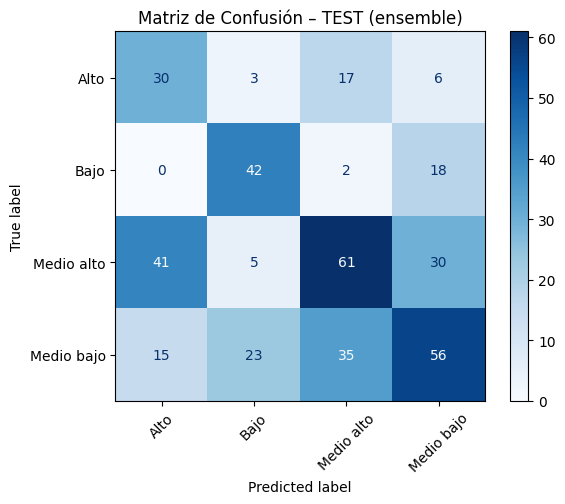

In [7]:
# Evaluación
best_idx = np.argmax([res["ensemble_macro_f1"] for res in resultados_grid])
best_config = resultados_grid[best_idx]
best_preds  = ensemble_preds_test[best_idx]
best_probs  = ensemble_probs_test[best_idx]

print(f"\nMejor configuración de ensemble: {best_config}")
print("=== Reporte de Clasificación (TEST, ensemble) ===")
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))

cm_ensemble = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm_ensemble, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión – TEST (ensemble)")
plt.show()



In [8]:
# AUC
auc_dict = {}
for i, class_name in enumerate(label_encoder.classes_):
    auc_score = roc_auc_score((y_test == i).astype(int), best_probs[:, i])
    auc_dict[class_name] = auc_score

# Tabla integrada
results_table = []
class_report = classification_report(y_test, best_preds, target_names=label_encoder.classes_, output_dict=True)
for cls in label_encoder.classes_:
    results_table.append({
        "model": "BETO test",
        "class": cls,
        "precision": class_report[cls]['precision'],
        "recall": class_report[cls]['recall'],
        "f1": class_report[cls]['f1-score'],
        "support": class_report[cls]['support'],
        "auc": auc_dict[cls]
    })
df_auc_classes = pd.DataFrame(results_table)
print(df_auc_classes)



       model       class  precision    recall        f1  support       auc
0  BETO test        Alto   0.348837  0.535714  0.422535     56.0  0.772104
1  BETO test        Bajo   0.575342  0.677419  0.622222     62.0  0.921409
2  BETO test  Medio alto   0.530435  0.445255  0.484127    137.0  0.693726
3  BETO test  Medio bajo   0.509091  0.434109  0.468619    129.0  0.679799


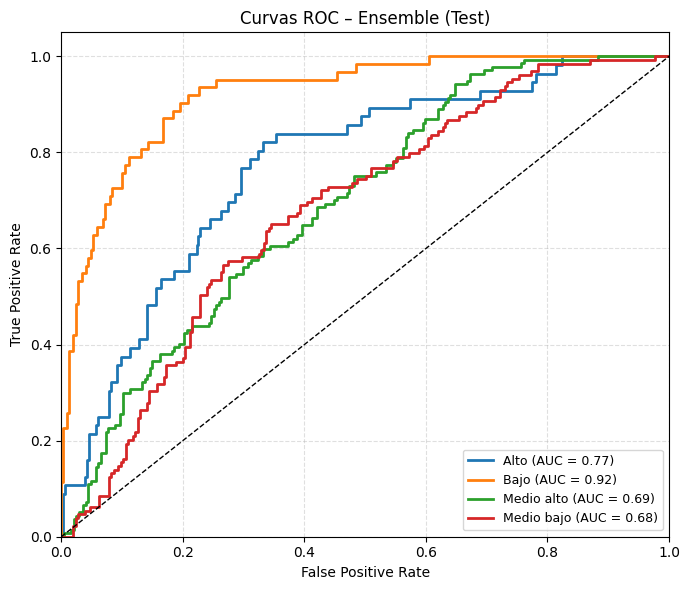

In [9]:
# Curvas
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Preparar datos ------------------------------------------------
y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
n_classes  = y_test_bin.shape[1]

plt.figure(figsize=(7, 6))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.2f})")

# Diagonal y estilo --------------------------------------------
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC – Ensemble (Test)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [10]:
# Limpieza
def liberar_memoria(model, optimizer=None):
    model.to("cpu")
    if optimizer:
        del optimizer
    torch.cuda.empty_cache()
    gc.collect()
    print("Memoria de GPU liberada.")

liberar_memoria(model=model, optimizer=optimizer)

#              precision    recall  f1-score   support

#         Alto       0.30      0.64      0.40        56
#         Bajo       0.60      0.61      0.61        62
#   Medio alto       0.46      0.37      0.41       137
#   Medio bajo       0.52      0.36      0.42       129

#     accuracy                           0.45       384
#    macro avg       0.47      0.50      0.46       384
# weighted avg       0.48      0.45      0.45       384

#        model       class  precision    recall        f1  support       auc
# 0  BETO test        Alto   0.295082  0.642857  0.404494     56.0  0.767694
# 1  BETO test        Bajo   0.603175  0.612903  0.608000     62.0  0.891354
# 2  BETO test  Medio alto   0.459459  0.372263  0.411290    137.0  0.706729
# 3  BETO test  Medio bajo   0.522727  0.356589  0.423963    129.0  0.698434
# Memoria de GPU liberada.


Memoria de GPU liberada.
